# Projeto Prático - Fase Final  
## Novas Tecnologias em Banco de Dados  
### Tema: Wikipedia - Serial Killers  
### Grupo 3  

**Integrantes:**  
- Amanda Akemi Perina Kouchi
- Daniel Oliveira Rocha

**Disciplina:** Novas Tecnologias em Banco de Dados  
**Professora:** Profa. Dra. Sahudy Montenegro González  
**Data:** 9 de Dezembro de 2025  

---

## Objetivos do Projeto
Este notebook apresenta a implementação completa do Data Warehouse desenvolvido a partir da extração e tratamento de dados provenientes da Wikipédia sobre serial killers.  
Inclui:  
- Modelagem dimensional  
- Processo de ETL  
- Construção das tabelas do DW  
- Consultas analíticas  
- Visualização dos resultados  
- Conclusões e contribuições 

O conteúdo apresentado neste notebook corresponde ao relatório da Fase Final.


# 1. Introdução ao Tema

O tema escolhido foi *Serial Killers*, utilizando como fonte principal a página da Wikipédia  “List of Serial Killers by Number of Victims”.  
A partir desses dados, o objetivo é estruturar um Data Warehouse (DW) que permita análise multidimensional envolvendo:

- número de vítimas  
- país(es) de atuação  
- duração da atividade criminosa  
- perfis demográficos (gênero, idade, país de origem)  
- distribuições temporais  

O DW viabiliza análises estratégicas para um gestor da área criminal, permitindo identificar padrões geográficos, temporais e comportamentais.


# 2. Requisitos de Negócio

As consultas analíticas definidas na Fase 1 são:

1. Qual a soma total de vítimas (confirmadas e possíveis) dos assassinos que atuaram em mais de um país?
2. Qual a idade média de início dos assassinatos por gênero?
3. A duração média dos anos em atividade diminuiu após o início do uso do teste de DNA em investigações criminais?
4. Comparando assassinos da América do Sul versus América do Norte que começaram suas atividades nos anos 1990, qual continente possui mais criminosos com status "PRESO"?


# 3. Modelo Multidimensional

A seguir está o diagrama do modelo em estrela utilizado no projeto.

### Figura 1 - Modelo dimensional do Data Warehouse
![image.png](./image.png "image.png")

O modelo é composto por:

- Tabela Fato: `Fato_Crimes`
- Dimensões:
  - `Dim_Assassino`
  - `Dim_Tempo`
  - `Dim_Localizacao`
  - `Ponte_Localizacao`

Durante o processo de ETL serão realizadas as seguintes ações:
- Remoção de caracteres especiais e hyperlinks de nomes e descrições;
- Separação de valores compostos (ex: 1954-1978 para início = 1954, fim = 1978);
- Conversão de valores em texto para numérico (como os números de vítimas);
- Padronização de valores (ex: status);
- Padronização linguística: nomes de países e territórios em inglês, tudo em letras maiúsculas.

As seguintes fontes de dados foram definidas:
- Fonte 1 (principal): A tabela na página “Lista de Serial Killers por Número de Vítimas” do Wikipédia.
- Fonte 2 (secundária): As páginas individuais da Wikipédia para cada assassino.
- Fonte 3 (interna): Lógica de ETL (Cálculos, Regras de Negócio, Tabelas de Lookup).

A Tabela 1 a seguir ilustra as transformações necessárias por dimensão do DW:
### Tabela 1 - Relação dimensão-ação

  | Tabela Destino      | Atributo Destino     | Fonte de Dados | Atributo Origem / Lógica | ETL / Transformações |
|---------------------|-----------------------|-----------------|---------------------------|-----------------------|
| **Dim_Tempo**       | chave_tempo           | Interna (Fonte 3) | N/A | Geração de surrogate key |
| **Dim_Tempo**       | ano                   | Fonte 1 (Principal) | "Anos em atividade" | Extrair ano inicial e final; criar registro único para cada ano |
| **Dim_Tempo**       | década                | Interna (Fonte 3) | ano | Cálculo da década (ex: 1992 → 1990) |
| **Dim_Localização** | chave_localizacao    | Interna (Fonte 3) | N/A | Surrogate key |
| **Dim_Localização** | país                  | Fonte 1 (Principal) | Coluna "País" | Separar por vírgula; padronizar maiúsculas; criar um registro por país |
| **Dim_Localização** | continente            | Interna (Fonte 3) | país | Associação manual (lookup): país → continente |
| **Dim_Assassino**   | chave_assassino       | Interna (Fonte 3) | N/A | Surrogate key |
| **Dim_Assassino**   | nome_assassino        | Fonte 1 (Principal) | Coluna "Nome" | Remover espaços e caracteres especiais |
| **Dim_Assassino**   | genero                | Fonte 2 (Secundária) | Página individual | Scraping de pronomes; padronizar para MASCULINO/FEMININO/N/A |
| **Dim_Assassino**   | ano_de_nascimento     | Fonte 2 (Secundária) | Infobox "Born" | Extrair ano da data; converter para inteiro |
| **Dim_Assassino**   | pais_de_origem        | Fonte 2 (Secundária) | Infobox "Born" | Extrair país; padronizar |
| **Dim_Assassino**   | status                | Fonte 2 (Secundária) | Infobox ("Died", "Criminal Penalty") | Lógica: se "Died" → MORTO; se "Life" → PRESO; senão avaliar sentença |
| **Ponte_Localização** | chave_ponte_local   | Interna (Fonte 3) | N/A | Surrogate key para grupo de países |
| **Ponte_Localização** | chave_localizacao   | Fonte 1 + Interna | "País" + Dim_Localização | Separar países; fazer lookup de cada chave_localização; gerar múltiplas linhas |
| **Fato_Crimes**     | chave_ano_inicio      | Fonte 1 + Dim_Tempo | "Anos em atividade" | Extrair ano inicial; lookup na Dim_Tempo |
| **Fato_Crimes**     | chave_ano_final       | Fonte 1 + Dim_Tempo | "Anos em atividade" | Extrair ano final; lookup na Dim_Tempo |
| **Fato_Crimes**     | chave_ponte_local     | Fonte 3 | Tabela Ponte_Localização | Usar chave gerada para grupo de países |
| **Fato_Crimes**     | chave_assassino       | Fonte 1 + Dim_Assassino | Nome | Lookup da surrogate key |
| **Fato_Crimes**     | vitimas_possiveis     | Fonte 1 (Principal) | "Vítimas possíveis" | Remover caracteres não numéricos; converter para inteiro; substituir nulos por 0 |
| **Fato_Crimes**     | vitimas_confirmadas   | Fonte 1 (Principal) | "Vítimas provadas" | Limpeza; conversão para inteiro; substituir nulos por 0 |
| **Fato_Crimes**     | quantidade_de_paises  | Fonte 3 | Ponte_Localização | COUNT do número de países associados ao grupo |
| **Fato_Crimes**     | anos_em_atividade     | Fonte 1 | "Anos em atividade" | Cálculo: ano_final − ano_inicio |
| **Fato_Crimes**     | idade_de_inicio       | Fonte 1 + Fonte 2 | Ano_Inicio + Ano_Nascimento | Cálculo: Ano_Inicio − Ano_Nascimento |



# 4. Implementação do ETL

A implementação do pipeline foi realizada em PySpark no Databricks, estruturada nas camadas **Bronze**, **Prata** e **Ouro**, seguindo o aprendido em aula e garantindo limpeza e qualidade dos dados antes da carga no modelo dimensional.
  


## 4.1 Camada Bronze - Ingestão de Dados Brutos

Nesta camada foram armazenados os dados exatamente como vieram das fontes externas:

- **Fonte 1:** dataset principal  
- **Fonte 2:** scraping individual das páginas dos assassinos  
- **Fonte 3:** tabelas auxiliares geradas internamente  
- **Formato:** JSON (mesmo da Wikipedia)
- **Objetivo:** manter os dados originais para processamento

Abaixo está o código para a camada bronze.


In [0]:
%pip install wikipedia-api

  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for wikipedia-api: filename=Wikipedia_API-0.8.1-py3-none-any.whl size=15383 sha256=b17bdee1f57f4de309943bfabea1a7d548f74f5837cd6ce72cb9f4c08a8c4240
  Stored in directory: /home/spark-ba9a1ebd-6d4b-4e70-bbf9-1b/.cache/pip/wheels/33/3c/79/b36253689d838af4a0539782853ac3cc38a83a6591ad570dde
Successfully built wikipedia-api
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.


In [0]:
dbutils.library.restartPython()

In [0]:
import requests
from bs4 import BeautifulSoup
from pyspark.sql import SparkSession
import pandas as pd
import re
import urllib.parse
import wikipediaapi

# wikipedia exige um User-Agent chatões
headers = {
    'User-Agent': 'ProjetoNTBD_UFSCar/1.0 (estudante@ufscar.br)'
}

# objeto wiki_wiki usado para buscar texto limpo
wiki_wiki = wikipediaapi.Wikipedia(
    user_agent=headers['User-Agent'],
    language='en'
)

def get_killer_details(url_suffix):
    full_url = f"https://en.wikipedia.org{url_suffix}"
    try:
        response = requests.get(full_url, headers=headers)
        if response.status_code != 200:
            print(f"Falha ao acessar {full_url}: Status {response.status_code}")
            return None
        
        soup = BeautifulSoup(response.text, 'html.parser')
        infobox = soup.find('table', {'class': 'infobox'})
        
        data = {
            'gender': 'N/A',
            'birth_year': None,
            'country_origin': None,
            'status': 'FORAGIDO'
        }

        if not infobox:
            return None

        page_title = urllib.parse.unquote(url_suffix.split('/')[-1])
        page_obj = wiki_wiki.page(page_title)

        if page_obj.exists():
            api_text = page_obj.text

            male_regex = re.compile(r"\b(he|his|him|he's|he'd|he\'s|he\'d|himself)\b", re.IGNORECASE)
            female_regex = re.compile(r"\b(she|her|hers|she's|she'd|she\'s|she\'d|herself)\b", re.IGNORECASE)

            male_match = male_regex.search(api_text)
            female_match = female_regex.search(api_text)

            idx_male = male_match.start() if male_match else float('inf')
            idx_female = female_match.start() if female_match else float('inf')
            
            # O pronome que aparecer primeiro ganha
            if idx_male < idx_female:
                data['gender'] = 'MASCULINO'
            elif idx_female < idx_male:
                data['gender'] = 'FEMININO'


        # varredura da infobox
        rows = infobox.find_all('tr')
        
        found_country = False
        tags_indicating_prison = [
            'date apprehended', 'penalty', 'criminal penalty', 
            'imprisoned at', 'conviction', 'convicted', 'sentence'
        ]
        
        for row in rows:
            header = row.find('th')
            value = row.find('td')
            
            if header and value:
                header_text = header.get_text().strip().lower()
                value_text = value.get_text().strip()

                # ano de nascimento
                if 'born' in header_text:
                    year_match = re.search(r'\d{4}', value_text)
                    if year_match:
                        data['birth_year'] = int(year_match.group(0))
                                        
                    parts = value_text.split(',')
                    if len(parts) > 0:
                        country_candidate = re.sub(r'\[.*?\]', '', parts[-1]).strip()
                        if not any(char.isdigit() for char in country_candidate):
                            data['country_origin'] = country_candidate.upper()
                            found_country = True
                
                # país
                if not found_country:
                    if 'country' in header_text:
                        data['country_origin'] = value_text.split('[')[0].strip().upper()
                        found_country = True
                
                

                # status
                if any(tag in header_text for tag in tags_indicating_prison):
                    data['status'] = 'PRESO'

        return data

    except Exception as e:
        print(f"Erro ao processar {full_url}: {e}")
        return None


main_url = "https://en.wikipedia.org/wiki/List_of_serial_killers_by_number_of_victims"
print(f"Acessando {main_url}...")

resp = requests.get(main_url, headers=headers)

if resp.status_code != 200:
    print(f"ERRO CRÍTICO: Status Code: {resp.status_code}")
else:
    soup_main = BeautifulSoup(resp.text, 'html.parser')
    serial_killers_data = []

    target_keywords = [
        "highest known victim count",
        "15 to 30",
        "5 to 14",
        "fewer than five"
    ]

    excluded_keywords = [
        "medical professionals",
        "groups",
        "disputed"
    ]

    #classe wikitable é padrão para tabelas de dados na Wikipedia
    tables = soup_main.find_all('table', {'class': 'wikitable'})
    
    print(f"Encontradas {len(tables)} tabelas 'wikitable' na página. Analisando seções...")

    for table in tables:
        # encontra o cabeçalho h2 ou h3 anterior a tabela ignora p div que estejam no meio do caminho
        prev_header = table.find_previous(['h2', 'h3'])
        
        if not prev_header:
            continue

        header_text = prev_header.get_text().lower()
        
        # verificar se é uma seção alvo e não é excluída
        is_target = any(t in header_text for t in target_keywords)
        is_excluded = any(e in header_text for e in excluded_keywords)

        if is_target and not is_excluded:
            print(f"\n>>> PROCESSANDO TABELA DA SEÇÃO: '{header_text.strip()}'")
            
            rows = table.find_all('tr')[1:] # pula o cabeçalho da tabela
            
            for row in rows:
                cols = row.find_all('td')
                if len(cols) < 4: continue
                
                # coluna 0 é o nome do assassino
                name_col = cols[0]
                link_tag = name_col.find('a')
                
                if not link_tag: continue 
                
                name = link_tag.get_text().strip()
                url_suffix = link_tag['href']
                
                if "redlink=1" in url_suffix: continue

                print(f"   -> Coletando: {name}")
                
                # dados básicos tabela principal
                # tratamento de erro simples caso a coluna mude de lugar ou falte texto
                try:
                    country_active = cols[1].get_text().strip()
                    years_active = cols[2].get_text().strip()
                    
                    proven_text = cols[3].get_text().strip()
                    possible_text = cols[4].get_text().strip()
                    
                    proven_match = re.search(r'\d+', proven_text)
                    proven_count = int(proven_match.group(0)) if proven_match else 0
                    
                    possible_match = re.search(r'\d+', possible_text)
                    possible_count = int(possible_match.group(0)) if possible_match else 0
                except Exception as e:
                    print(f"      Erro ao ler colunas da tabela principal: {e}")
                    continue

                # detalhamento página individual
                details = get_killer_details(url_suffix)
                
                if details:
                    row_data = {
                        "nome_assassino": name,
                        "pais_atuacao": country_active,
                        "anos_atividade": years_active,
                        "vitimas_provadas": proven_count,
                        "vitimas_possiveis": possible_count,
                        "genero": details['gender'],
                        "ano_nascimento": details['birth_year'],
                        "pais_origem": details['country_origin'],
                        "status": details['status']
                    }
                    serial_killers_data.append(row_data)
                
    print(f"\nTotal coletado: {len(serial_killers_data)}")

    if len(serial_killers_data) > 0:
        pdf = pd.DataFrame(serial_killers_data)
        pdf['ano_nascimento'] = pdf['ano_nascimento'].astype('Int64') 
        df_bronze = spark.createDataFrame(pdf)
        display(df_bronze)       
        caminho_destino = "/Volumes/workspace/public/data/delta/camadabronze/serial_killers_raw"
        df_bronze.write.format("delta").mode("overwrite").save(caminho_destino)
    else:
        print("Nenhum dado foi coletado.")

Acessando https://en.wikipedia.org/wiki/List_of_serial_killers_by_number_of_victims...
Encontradas 7 tabelas 'wikitable' na página. Analisando seções...

>>> PROCESSANDO TABELA DA SEÇÃO: 'serial killers with the highest known victim count'
   -> Coletando: Luis Garavito
   -> Coletando: Mariam Soulakiotis
   -> Coletando: Pedro López
   -> Coletando: Javed Iqbal
   -> Coletando: Mikhail Popkov
   -> Coletando: Daniel Camargo Barbosa
   -> Coletando: Pedro Rodrigues Filho
   -> Coletando: Kampatimar Shankariya
   -> Coletando: Hoshang Amini
   -> Coletando: Yang Xinhai
   -> Coletando: Abul Djabar
   -> Coletando: Samuel Little
   -> Coletando: William Unek
   -> Coletando: Mohammed Bijeh
   -> Coletando: Andrei Chikatilo
   -> Coletando: Anatoly Onoprienko
   -> Coletando: Florisvaldo de Oliveira
   -> Coletando: Gary Ridgway
   -> Coletando: Alexander Pichushkin
   -> Coletando: Wang Qiang
   -> Coletando: Ahmad Suradji
   -> Coletando: Raman Raghav
   -> Coletando: Moses Sithole
   -

nome_assassino,pais_atuacao,anos_atividade,vitimas_provadas,vitimas_possiveis,genero,ano_nascimento,pais_origem,status
Luis Garavito,Colombia Ecuador[3] Venezuela[3],1992–1999[3],193,194,MASCULINO,1957,COLOMBIA,PRESO
Mariam Soulakiotis,Greece,1939–1951,177,500,FEMININO,1883,GREECE,PRESO
Pedro López,Colombia Peru Ecuador,1969–1980,110,300,MASCULINO,1948,COLOMBIA,PRESO
Javed Iqbal,Pakistan,1998–1999,100,100,MASCULINO,1961,PAKISTAN,PRESO
Mikhail Popkov,Russia,1992–2010,83,86,MASCULINO,1964,USSR,PRESO
Daniel Camargo Barbosa,Colombia Ecuador Brazil (alleged)[20],1974–1986,72,180,MASCULINO,1930,COLOMBIA,PRESO
Pedro Rodrigues Filho,Brazil,1967–2003,71,100,MASCULINO,1954,BRAZIL,PRESO
Kampatimar Shankariya,India,1977–1978,70,70,MASCULINO,1952,INDIA,PRESO
Hoshang Amini,Iran,1954–1962,67,67,MASCULINO,1936,IRAN,PRESO
Yang Xinhai,China,2000–2003,67,67,MASCULINO,1968,CHINA,PRESO


## 4.2 Camada Prata - Limpeza e Padronização

Nesta camada foram aplicadas as transformações necessárias para corrigir formatos, tratar valores nulos, padronizar colunas e preparar as dimensões e fatos.

Principais transformações realizadas:

- Remoção de caracteres especiais  
- Extração de anos (início e fim)
- Separação de múltiplos países  
- Padronização de nome e país  
- Criação de colunas derivadas  

A seguir, apresentamos o código da camada Prata.


In [0]:
from pyspark.sql.functions import (col, regexp_replace, trim, upper, when, 
                                   length, split, regexp_extract, lit, 
                                   current_date, year, array_remove, transform, array_distinct)
from pyspark.sql.types import IntegerType

# ler df bronze
caminho_bronze = "/Volumes/workspace/public/data/delta/camadabronze/serial_killers_raw"
df = spark.read.format("delta").load(caminho_bronze)

# há uma linha a ser removida pois venho com muito lixo do scraper, não dá para salvar
df = df.filter(~col("pais_origem").contains("CIRCUMSTANTIAL EVIDENCE"))

# função de limpeza e ajustes finos
def limpar_coluna_pais(coluna):
    # converter espaço não-quebrável em espaço normal
    c = regexp_replace(col(coluna), r"\xa0", " ")
    
    # remover parenteses e números soltos
    c = upper(trim(regexp_replace(c, r"[\(\)\[\]\d]", "")))
    
    # remoção de casos específics de lixo do scraper
    lixo_scraper = [
        "GABRIEL GARZA", "ABUL DJABAR", "MAAKE", "MAOUPA CEDRIC", 
        "JOHANNES MASHIANE", "HOTH", "THEN EAST PAKISTAN", "UNCONFIRMED",
        "ALLEGED", "POSSIBLE", "CLAIMED"
    ]
    for lixo in lixo_scraper:
        c = regexp_replace(c, lixo, "")

    # remove SR solto SR SLOVENIA -> SLOVENIA
    c = regexp_replace(c, r"\bSR\b", "") 
    
    # casos específicos
    c = regexp_replace(c, r"BELGIAN CONGO", "DR CONGO")
    c = regexp_replace(c, r"TANGANYIKA", "TANZANIA")
    c = regexp_replace(c, r"PORTUGUESE ANGOLA", "ANGOLA")
    c = regexp_replace(c, r"MARTINIQUE", "FRANCE")
    c = regexp_replace(c, r"REPUBLIC OF MACEDONIA", "NORTH MACEDONIA")
    c = regexp_replace(c, r"\bRSFSR\b", "USSR")
    c = regexp_replace(c, r"RUSSIAN EMPIRE", "RUSSIA")
    c = regexp_replace(c, r".*SOVIET.*|.*SSR\b", "USSR")
    c = regexp_replace(c, r"\bU\.?S\.?A?\.?\b|MASSACHUSETTS", "UNITED STATES")
    c = regexp_replace(c, r"\bUK\b|\bU\.K\b", "UNITED KINGDOM")
    c = regexp_replace(c, r".*UNITED KINGDOM.*|.*ENGLAND.*|.*SCOTLAND.*|.*WALES.*", "UNITED KINGDOM")
    c = regexp_replace(c, r".*GERMAN.*|.*PRUSSIA.*", "GERMANY")
    c = regexp_replace(c, r".*AUSTRIA.*", "AUSTRIA") 
    c = regexp_replace(c, r".*BRAZIL.*|SÃO JOSÉ DO RIO PRETO", "BRAZIL")
    c = regexp_replace(c, r".*SOUTH AFRICA.*|CAPE COLONY", "SOUTH AFRICA")
    c = regexp_replace(c, r".*SWAZILAND.*|.*ESWATINI.*", "SWAZILAND")
    c = regexp_replace(c, r"FRENCH INDOCHINA", "VIETNAM")
    c = regexp_replace(c, r".*BANGLADESH.*", "BANGLADESH")
    c = regexp_replace(c, r".*JAPAN.*", "JAPAN")
    c = regexp_replace(c, r".*IRAN.*", "IRAN")
    c = regexp_replace(c, r".*SPAIN.*|CANARY ISLANDS", "SPAIN")
    c = regexp_replace(c, r"PROTECTORATE OF UGANDA", "UGANDA")
    c = regexp_replace(c, r"FRENCH TUNISIA", "TUNISIA")
    c = regexp_replace(c, r"UTTAR PRADESH", "INDIA")
    c = regexp_replace(c, r"CEYLON", "SRI LANKA")
    c = regexp_replace(c, r"ZAIRE", "DR CONGO")
    c = regexp_replace(c, r"ONTARIO CANADA", "CANADA")
    c = regexp_replace(c, r".*NETHERLANDS.*", "NETHERLANDS")
    c = regexp_replace(c, r".*ROMANIA.*", "ROMANIA")
    c = regexp_replace(c, r".*POLAND.*|.*POLISH.*", "POLAND")
    c = regexp_replace(c, r".*YUGOSLAVIA.*", "YUGOSLAVIA")
    c = regexp_replace(c, r".*CZECHOSLOVAKIA.*", "CZECHOSLOVAKIA")

    # blindar nomes compostos para split
    paises_compostos = [
        "TRINIDAD AND TOBAGO", "BOSNIA AND HERZEGOVINA", "SAO TOME AND PRINCIPE",
        "PAPUA NEW GUINEA", "CENTRAL AFRICAN REPUBLIC", "DOMINICAN REPUBLIC",
        "UNITED KINGDOM", "UNITED STATES", "SOUTH AFRICA", "SAUDI ARABIA",
        "HONG KONG", "CZECH REPUBLIC", "SRI LANKA", "DR CONGO", "NEW ZEALAND",
        "COSTA RICA", "EL SALVADOR", "SIERRA LEONE", "BURKINA FASO",
        "EQUATORIAL GUINEA", "NORTH MACEDONIA", "IVORY COAST",
        "SOUTH KOREA", "NORTH KOREA", "WEST GERMANY", "EAST GERMANY",
        "AUSTRIA HUNGARY", "SERBIA AND MONTENEGRO", "BELGIAN CONGO" # Silvio Plut você me paga
    ]
    
    for pais in paises_compostos:
        pais_token = pais.replace(" ", "_")
        c = regexp_replace(c, pais, pais_token)

    # limpeza final
    c = regexp_replace(c, r"[,\-\/]+", " ")
    c = regexp_replace(c, r"[\. ]+$", "") 
    c = regexp_replace(c, " +", " ")
    
    return trim(c)


df_clean = (df.withColumn("nome_assassino", trim(regexp_replace(col("nome_assassino"), r"\[.*?\]", "")))
              .withColumn("pais_atuacao_temp", limpar_coluna_pais("pais_atuacao"))
              .withColumn("pais_origem", limpar_coluna_pais("pais_origem"))) 

# correção pontual Sek Kim Wah
df_clean = df_clean.withColumn("pais_origem", 
                               when(col("nome_assassino").contains("Sek Kim Wah"), "SINGAPORE")
                               .otherwise(col("pais_origem")))

# gerar array
df_clean = df_clean.withColumn("pais_atuacao", split(col("pais_atuacao_temp"), " "))

# destokeniza e limpa duplicados
df_clean = df_clean.withColumn("pais_atuacao", 
    transform(
        array_distinct(array_remove(col("pais_atuacao"), "")), 
        lambda x: regexp_replace(x, "_", " ")
    )
)
df_clean = df_clean.withColumn("pais_origem", regexp_replace(col("pais_origem"), "_", " "))

# datas
df_clean = df_clean.withColumn("raw_start", regexp_extract(col("anos_atividade"), r"(\d{4})", 1))
df_clean = df_clean.withColumn("raw_end", regexp_extract(col("anos_atividade"), r"(\d{4}).*?(\d{4})", 2))
df_clean = df_clean.withColumn("decade_base", regexp_extract(col("anos_atividade"), r"(\d{4})s", 1))

df_transformed = (df_clean.withColumn("ano_inicio", 
    when(col("anos_atividade").contains("earlier"), None)
    .when(col("decade_base") != "", col("decade_base").cast(IntegerType()))
    .otherwise(col("raw_start").cast(IntegerType()))
).withColumn("ano_final",
    when(col("anos_atividade").contains("earlier"), col("raw_start").cast(IntegerType()))
    .when(col("decade_base") != "", col("decade_base").cast(IntegerType()) + 9)
    .when(col("anos_atividade").contains("present"), year(current_date()))
    .when((col("raw_end") == "") & (col("raw_start") != ""), col("raw_start").cast(IntegerType()))
    .otherwise(col("raw_end").cast(IntegerType()))
))

df_final = (df_transformed.withColumn("status", upper(col("status")))
                          .withColumn("genero", upper(col("genero"))))

df_final = df_final.withColumn("pais_origem", when(length(col("pais_origem")) < 2, None).otherwise(col("pais_origem")))

# seleção Final
df_silver = df_final.select(
    "nome_assassino", "genero", "ano_nascimento", 
    "pais_origem", "pais_atuacao", 
    "ano_inicio", "ano_final", 
    "vitimas_provadas", "vitimas_possiveis", "status"
)

display(df_silver)

# salvar
df_silver.write.format("delta").mode("overwrite").option("mergeSchema", "true").saveAsTable("workspace.public.serial_killers_silver")

nome_assassino,genero,ano_nascimento,pais_origem,pais_atuacao,ano_inicio,ano_final,vitimas_provadas,vitimas_possiveis,status
Luis Garavito,MASCULINO,1957,COLOMBIA,"List(COLOMBIA, ECUADOR, VENEZUELA)",1992,1999,193,194,PRESO
Mariam Soulakiotis,FEMININO,1883,GREECE,List(GREECE),1939,1951,177,500,PRESO
Pedro López,MASCULINO,1948,COLOMBIA,"List(COLOMBIA, PERU, ECUADOR)",1969,1980,110,300,PRESO
Javed Iqbal,MASCULINO,1961,PAKISTAN,List(PAKISTAN),1998,1999,100,100,PRESO
Mikhail Popkov,MASCULINO,1964,USSR,List(RUSSIA),1992,2010,83,86,PRESO
Daniel Camargo Barbosa,MASCULINO,1930,COLOMBIA,List(BRAZIL),1974,1986,72,180,PRESO
Pedro Rodrigues Filho,MASCULINO,1954,BRAZIL,List(BRAZIL),1967,2003,71,100,PRESO
Kampatimar Shankariya,MASCULINO,1952,INDIA,List(INDIA),1977,1978,70,70,PRESO
Hoshang Amini,MASCULINO,1936,IRAN,List(IRAN),1954,1962,67,67,PRESO
Yang Xinhai,MASCULINO,1968,CHINA,List(CHINA),2000,2003,67,67,PRESO


## 4.3 Camada Ouro - Modelo Dimensional

Nesta última camada, os dados já limpos e padronizados foram estruturados no formato estrela, contendo:

### Dimensões criadas:
- Dim_Assassino  
- Dim_Localização  
- Dim_Tempo  

### Tabela Fato:
- Fato_Crimes

### Tabela Ponte:
- Ponte_Localização (assassino → múltiplos países)

As chaves substitutas (surrogate keys) foram geradas para todas as dimensões.

A seguir, apresentamos as tabelas finais e seus códigos.


### 4.3.1 Dimensão Localização

In [0]:
from pyspark.sql.functions import col, lit, create_map, explode, row_number, when, coalesce
from pyspark.sql.window import Window
from pyspark.sql.types import StringType, IntegerType

# carregar df prata
df_silver = spark.table("workspace.public.serial_killers_silver")

# obter países de atuação, explodindo o array
df_paises = df_silver.select(explode(col("pais_atuacao")).alias("pais")) \
                     .filter(col("pais").isNotNull()) \
                     .filter(col("pais") != "") \
                     .distinct() \
                     .orderBy("pais")

# mapeamente feito com ajuda de um github e um programinha em C
mapa_continentes = {
    "ANDORRA": "EUROPE",
    "UNITED ARAB EMIRATES": "ASIA",
    "AFGHANISTAN": "ASIA",
    "ANTIGUA AND BARBUDA": "NORTH AMERICA",
    "ANGUILLA": "NORTH AMERICA",
    "ALBANIA": "EUROPE",
    "ARMENIA": "ASIA",
    "ANGOLA": "AFRICA",
    "ANTARCTICA": "ANTARCTICA",
    "ARGENTINA": "SOUTH AMERICA",
    "AMERICAN SAMOA": "OCEANIA",
    "AUSTRIA": "EUROPE",
    "AUSTRALIA": "OCEANIA",
    "ARUBA": "NORTH AMERICA",
    "ÅLAND ISLANDS": "EUROPE",
    "AZERBAIJAN": "ASIA",
    "BOSNIA AND HERZEGOVINA": "EUROPE",
    "BARBADOS": "NORTH AMERICA",
    "BANGLADESH": "ASIA",
    "BELGIUM": "EUROPE",
    "BURKINA FASO": "AFRICA",
    "BULGARIA": "EUROPE",
    "BAHRAIN": "ASIA",
    "BURUNDI": "AFRICA",
    "BENIN": "AFRICA",
    "SAINT BARTHÉLEMY": "NORTH AMERICA",
    "BERMUDA": "NORTH AMERICA",
    "BRUNEI DARUSSALAM": "ASIA",
    "BOLIVIA": "SOUTH AMERICA",
    "BONAIRE, SINT EUSTATIUS AND SABA": "NORTH AMERICA",
    "BRAZIL": "SOUTH AMERICA",
    "BAHAMAS": "NORTH AMERICA",
    "BHUTAN": "ASIA",
    "BOUVET ISLAND (BOUVETOYA)": "ANTARCTICA",
    "BOTSWANA": "AFRICA",
    "BELARUS": "EUROPE",
    "BELIZE": "NORTH AMERICA",
    "CANADA": "NORTH AMERICA",
    "COCOS (KEELING) ISLANDS": "ASIA",
    "DR CONGO": "AFRICA",
    "CENTRAL AFRICAN REPUBLIC": "AFRICA",
    "SWITZERLAND": "EUROPE",
    "COTE D'IVOIRE": "AFRICA",
    "COOK ISLANDS": "OCEANIA",
    "CHILE": "SOUTH AMERICA",
    "CAMEROON": "AFRICA",
    "CHINA": "ASIA",
    "COLOMBIA": "SOUTH AMERICA",
    "COSTA RICA": "NORTH AMERICA",
    "CUBA": "NORTH AMERICA",
    "CAPE VERDE": "AFRICA",
    "CURAÇAO": "NORTH AMERICA",
    "CHRISTMAS ISLAND": "ASIA",
    "CYPRUS": "ASIA",
    "CZECH REPUBLIC": "EUROPE",
    "GERMANY": "EUROPE",
    "DJIBOUTI": "AFRICA",
    "DENMARK": "EUROPE",
    "DOMINICA": "NORTH AMERICA",
    "DOMINICAN REPUBLIC": "NORTH AMERICA",
    "ALGERIA": "AFRICA",
    "ECUADOR": "SOUTH AMERICA",
    "ESTONIA": "EUROPE",
    "EGYPT": "AFRICA",
    "WESTERN SAHARA": "AFRICA",
    "ERITREA": "AFRICA",
    "SPAIN": "EUROPE",
    "ETHIOPIA": "AFRICA",
    "FINLAND": "EUROPE",
    "FIJI": "OCEANIA",
    "FALKLAND ISLANDS (MALVINAS)": "SOUTH AMERICA",
    "MICRONESIA": "OCEANIA",
    "FAROE ISLANDS": "EUROPE",
    "FRANCE": "EUROPE",
    "GABON": "AFRICA",
    "UNITED KINGDOM": "EUROPE",
    "GRENADA": "NORTH AMERICA",
    "GEORGIA": "ASIA",
    "FRENCH GUIANA": "SOUTH AMERICA",
    "GUERNSEY": "EUROPE",
    "GHANA": "AFRICA",
    "GIBRALTAR": "EUROPE",
    "GREENLAND": "NORTH AMERICA",
    "GAMBIA": "AFRICA",
    "GUINEA": "AFRICA",
    "GUADELOUPE": "NORTH AMERICA",
    "EQUATORIAL GUINEA": "AFRICA",
    "GREECE": "EUROPE",
    "SOUTH GEORGIA AND THE SOUTH SANDWICH ISLANDS": "ANTARCTICA",
    "GUATEMALA": "NORTH AMERICA",
    "GUAM": "OCEANIA",
    "GUINEA-BISSAU": "AFRICA",
    "GUYANA": "SOUTH AMERICA",
    "HONG KONG": "ASIA",
    "HEARD ISLAND AND MCDONALD ISLANDS": "ANTARCTICA",
    "HONDURAS": "NORTH AMERICA",
    "CROATIA": "EUROPE",
    "HAITI": "NORTH AMERICA",
    "HUNGARY": "EUROPE",
    "INDONESIA": "ASIA",
    "IRELAND": "EUROPE",
    "ISRAEL": "ASIA",
    "ISLE OF MAN": "EUROPE",
    "INDIA": "ASIA",
    "BRITISH INDIAN OCEAN TERRITORY (CHAGOS ARCHIPELAGO)": "ASIA",
    "IRAQ": "ASIA",
    "IRAN": "ASIA",
    "ICELAND": "EUROPE",
    "ITALY": "EUROPE",
    "JERSEY": "EUROPE",
    "JAMAICA": "NORTH AMERICA",
    "JORDAN": "ASIA",
    "JAPAN": "ASIA",
    "KENYA": "AFRICA",
    "KYRGYZ REPUBLIC": "ASIA",
    "CAMBODIA": "ASIA",
    "KIRIBATI": "OCEANIA",
    "COMOROS": "AFRICA",
    "SAINT KITTS AND NEVIS": "NORTH AMERICA",
    "NORTH KOREA": "ASIA",
    "SOUTH KOREA": "ASIA",
    "KUWAIT": "ASIA",
    "CAYMAN ISLANDS": "NORTH AMERICA",
    "KAZAKHSTAN": "ASIA",
    "LAO PEOPLE'S DEMOCRATIC REPUBLIC": "ASIA",
    "LEBANON": "ASIA",
    "SAINT LUCIA": "NORTH AMERICA",
    "LIECHTENSTEIN": "EUROPE",
    "SRI LANKA": "ASIA",
    "LIBERIA": "AFRICA",
    "LESOTHO": "AFRICA",
    "LITHUANIA": "EUROPE",
    "LUXEMBOURG": "EUROPE",
    "LATVIA": "EUROPE",
    "LIBYA": "AFRICA",
    "MOROCCO": "AFRICA",
    "MONACO": "EUROPE",
    "MOLDOVA": "EUROPE",
    "MONTENEGRO": "EUROPE",
    "SAINT MARTIN": "NORTH AMERICA",
    "MADAGASCAR": "AFRICA",
    "MARSHALL ISLANDS": "OCEANIA",
    "MACEDONIA": "EUROPE",
    "MALI": "AFRICA",
    "MYANMAR": "ASIA",
    "MONGOLIA": "ASIA",
    "MACAO": "ASIA",
    "NORTHERN MARIANA ISLANDS": "OCEANIA",
    "MARTINIQUE": "NORTH AMERICA",
    "MAURITANIA": "AFRICA",
    "MONTSERRAT": "NORTH AMERICA",
    "MALTA": "EUROPE",
    "MAURITIUS": "AFRICA",
    "MALDIVES": "ASIA",
    "MALAWI": "AFRICA",
    "MEXICO": "NORTH AMERICA",
    "MALAYSIA": "ASIA",
    "MOZAMBIQUE": "AFRICA",
    "NAMIBIA": "AFRICA",
    "NEW CALEDONIA": "OCEANIA",
    "NIGER": "AFRICA",
    "NORFOLK ISLAND": "OCEANIA",
    "NIGERIA": "AFRICA",
    "NICARAGUA": "NORTH AMERICA",
    "NETHERLANDS": "EUROPE",
    "NORWAY": "EUROPE",
    "NEPAL": "ASIA",
    "NAURU": "OCEANIA",
    "NIUE": "OCEANIA",
    "NEW ZEALAND": "OCEANIA",
    "OMAN": "ASIA",
    "PANAMA": "NORTH AMERICA",
    "PERU": "SOUTH AMERICA",
    "FRENCH POLYNESIA": "OCEANIA",
    "PAPUA NEW GUINEA": "OCEANIA",
    "PHILIPPINES": "ASIA",
    "PAKISTAN": "ASIA",
    "POLAND": "EUROPE",
    "SAINT PIERRE AND MIQUELON": "NORTH AMERICA",
    "PITCAIRN ISLANDS": "OCEANIA",
    "PUERTO RICO": "NORTH AMERICA",
    "PALESTINIAN TERRITORY": "ASIA",
    "PORTUGAL": "EUROPE",
    "PALAU": "OCEANIA",
    "PARAGUAY": "SOUTH AMERICA",
    "QATAR": "ASIA",
    "RÉUNION": "AFRICA",
    "ROMANIA": "EUROPE",
    "SERBIA": "EUROPE",
    "RUSSIA": "EUROPE",
    "RWANDA": "AFRICA",
    "SAUDI ARABIA": "ASIA",
    "SOLOMON ISLANDS": "OCEANIA",
    "SEYCHELLES": "AFRICA",
    "SUDAN": "AFRICA",
    "SWEDEN": "EUROPE",
    "SINGAPORE": "ASIA",
    "SAINT HELENA, ASCENSION AND TRISTAN DA CUNHA": "AFRICA",
    "SLOVENIA": "EUROPE",
    "SVALBARD & JAN MAYEN ISLANDS": "EUROPE",
    "SLOVAKIA (SLOVAK REPUBLIC)": "EUROPE",
    "SIERRA LEONE": "AFRICA",
    "SAN MARINO": "EUROPE",
    "SENEGAL": "AFRICA",
    "SOMALIA": "AFRICA",
    "SURINAME": "SOUTH AMERICA",
    "SOUTH SUDAN": "AFRICA",
    "SAO TOME AND PRINCIPE": "AFRICA",
    "EL SALVADOR": "NORTH AMERICA",
    "SINT MAARTEN (DUTCH PART)": "NORTH AMERICA",
    "SYRIA": "ASIA",
    "SWAZILAND": "AFRICA",
    "TURKS AND CAICOS ISLANDS": "NORTH AMERICA",
    "CHAD": "AFRICA",
    "FRENCH SOUTHERN TERRITORIES": "ANTARCTICA",
    "TOGO": "AFRICA",
    "THAILAND": "ASIA",
    "TAJIKISTAN": "ASIA",
    "TOKELAU": "OCEANIA",
    "TIMOR-LESTE": "ASIA",
    "TURKMENISTAN": "ASIA",
    "TUNISIA": "AFRICA",
    "TONGA": "OCEANIA",
    "TURKEY": "ASIA",
    "TRINIDAD AND TOBAGO": "NORTH AMERICA",
    "TUVALU": "OCEANIA",
    "TAIWAN": "ASIA",
    "TANZANIA": "AFRICA",
    "UKRAINE": "EUROPE",
    "UGANDA": "AFRICA",
    "UNITED STATES MINOR OUTLYING ISLANDS": "OCEANIA",
    "UNITED STATES": "NORTH AMERICA",
    "URUGUAY": "SOUTH AMERICA",
    "UZBEKISTAN": "ASIA",
    "HOLY SEE (VATICAN CITY STATE)": "EUROPE",
    "SAINT VINCENT AND THE GRENADINES": "NORTH AMERICA",
    "VENEZUELA": "SOUTH AMERICA",
    "BRITISH VIRGIN ISLANDS": "NORTH AMERICA",
    "UNITED STATES VIRGIN ISLANDS": "NORTH AMERICA",
    "VIETNAM": "ASIA",
    "VANUATU": "OCEANIA",
    "WALLIS AND FUTUNA": "OCEANIA",
    "SAMOA": "OCEANIA",
    "YEMEN": "ASIA",
    "MAYOTTE": "AFRICA",
    "SOUTH AFRICA": "AFRICA",
    "ZAMBIA": "AFRICA",
    "ZIMBABWE": "AFRICA",
    "USSR": "EUROPE",
    "SOVIET UNION": "EUROPE",
    "YUGOSLAVIA": "EUROPE",
    "CZECHOSLOVAKIA": "EUROPE",
    "AUSTRIA HUNGARY": "EUROPE",
    "AUSTRIA-HUNGARY": "EUROPE",
    "SERBIA AND MONTENEGRO": "EUROPE",
    "EAST GERMANY": "EUROPE",
    "WEST GERMANY": "EUROPE",
    "IVORY COAST": "AFRICA",
    "LAOS": "ASIA",
    "NORTH MACEDONIA": "EUROPE",
    "ESWATINI": "AFRICA"
}
mapping_expr = create_map([lit(x) for x in sum(mapa_continentes.items(), ())])

dim_localizacao = df_paises.withColumn("continente", mapping_expr[col("pais")])

# tratamento de null no continente
dim_localizacao = dim_localizacao.fillna({"continente": "UNKNOWN"})

# id sequencial de localização
window_loc = Window.orderBy("pais")
dim_localizacao = dim_localizacao.withColumn("id_localizacao", row_number().over(window_loc))

dim_localizacao = dim_localizacao.select("id_localizacao", "pais", "continente")

schema_loc = dim_localizacao.schema

# linha para casos nulos
unknown_row = spark.createDataFrame([(-1, "UNKNOWN", "UNKNOWN")], schema_loc)
dim_localizacao = dim_localizacao.union(unknown_row).distinct()

display(dim_localizacao)
dim_localizacao.write.format("delta").mode("overwrite").saveAsTable("workspace.public.dim_localizacao")

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


id_localizacao,pais,continente
60,UKRAINE,EUROPE
22,ESTONIA,EUROPE
42,PANAMA,NORTH AMERICA
43,PERU,SOUTH AMERICA
26,HONG KONG,ASIA
9,BELIZE,NORTH AMERICA
15,COSTA RICA,NORTH AMERICA
35,MALAYSIA,ASIA
31,ITALY,EUROPE
40,NORTH MACEDONIA,EUROPE


### 4.3.2 Dimensão Tempo

In [0]:
# unir anos
anos_inicio = df_silver.select(col("ano_inicio").alias("ano"))
anos_fim = df_silver.select(col("ano_final").alias("ano"))
df_anos = anos_inicio.union(anos_fim).filter(col("ano").isNotNull()).distinct().orderBy("ano")

dim_tempo = df_anos.withColumn("decada", (col("ano") / 10).cast("int") * 10) \
                   .withColumn("seculo", (col("ano") / 100).cast("int") + 1) \
                   .withColumnRenamed("ano", "id_tempo")

# inserir para tempo desconhecido
schema_tempo = dim_tempo.schema
unknown_row_tempo = spark.createDataFrame([(-1, -1, -1)], schema_tempo)
dim_tempo = dim_tempo.union(unknown_row_tempo).distinct()

display(dim_tempo)
dim_tempo.write.format("delta").mode("overwrite").saveAsTable("workspace.public.dim_tempo")

id_tempo,decada,seculo
1914,1910,20
2014,2010,21
1944,1940,20
1945,1940,20
1980,1980,20
2001,2000,21
1955,1950,20
1947,1940,20
1984,1980,20
1994,1990,20


### 4.3.3 Dimensão Assassino

In [0]:
dim_assassino = df_silver.select(
    "nome_assassino",
    "genero",
    "ano_nascimento",
    "pais_origem",
    "status"
).distinct()

# tratamento de nulos
dim_assassino = dim_assassino.fillna({
    "genero": "UNKNOWN",
    "pais_origem": "UNKNOWN",
    "status": "UNKNOWN",
    "ano_nascimento": -1 # não sabe o nascimento usa -1
})

# ID para assassino
window_assassino = Window.orderBy("nome_assassino")
dim_assassino = dim_assassino.withColumn("id_assassino", row_number().over(window_assassino))
dim_assassino = dim_assassino.select("id_assassino", "nome_assassino", "genero", "ano_nascimento", "pais_origem", "status")

display(dim_assassino)
dim_assassino.write.format("delta").mode("overwrite").saveAsTable("workspace.public.dim_assassino")

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


id_assassino,nome_assassino,genero,ano_nascimento,pais_origem,status
1,Aalt Mondria,MASCULINO,1956,NETHERLANDS,PRESO
2,Abdallah al-Hubal,MASCULINO,1955,YEMEN,FORAGIDO
3,Abdufatto Zamanov,MASCULINO,1973,USSR,PRESO
4,Abdullah Shah,MASCULINO,1965,AFGHANISTAN,PRESO
5,Abul Djabar,MASCULINO,-1,AFGHANISTAN,PRESO
6,Adnan Çolak,MASCULINO,1952,TURKEY,PRESO
7,Adolf Seefeldt,MASCULINO,1870,GERMANY,PRESO
8,Adrián Arroyo Gutiérrez,MASCULINO,1976,COSTA RICA,PRESO
9,Ahmad Suradji,MASCULINO,1949,INDONESIA,PRESO
10,Aileen Wuornos,FEMININO,1956,UNITED STATES,PRESO


### 4.3.4 Ponte Localização

In [0]:
df_silver_ids = df_silver.join(dim_assassino, "nome_assassino", "inner")

df_exploded = df_silver_ids.select("id_assassino", explode("pais_atuacao").alias("pais_atuacao_single"))

dim_localizacao_df = spark.table("workspace.public.dim_localizacao")

# join com tratamento de null
# left join primeiro para ver quem não bate depois coalesce
ponte_localizacao = df_exploded.join(dim_localizacao_df, df_exploded.pais_atuacao_single == dim_localizacao_df.pais, "left") \
    .select(
        col("id_assassino"),
        coalesce(col("id_localizacao"), lit(-1)).alias("id_localizacao")
    )

display(ponte_localizacao)
ponte_localizacao.write.format("delta").mode("overwrite").saveAsTable("workspace.public.ponte_localizacao")

/databricks/python/lib/python3.12/site-packages/pyspark/sql/connect/expressions.py:1134: UserWarning: WARN WindowExpression: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
  warnings.warn(


id_assassino,id_localizacao
311,14
311,20
311,64
324,25
391,14
391,43
391,20
236,41
352,47
110,10


### 4.3.5 Fato Crimes

In [0]:
from pyspark.sql.functions import size, col, when, coalesce, lit

df_base = spark.table("workspace.public.serial_killers_silver").alias("base")
dim_ass = spark.table("workspace.public.dim_assassino").alias("dim_a")

df_fato = df_base.join(dim_ass, col("base.nome_assassino") == col("dim_a.nome_assassino"), "inner")

# ano_nascimento na dimensão pode ser -1 se for a idade fica errada
# se ano_nascimento for -1 ou ano_inicio for null então idade = -1
idade_calc = when((col("dim_a.ano_nascimento") == -1) | (col("base.ano_inicio").isNull()), -1) \
             .otherwise(col("base.ano_inicio") - col("dim_a.ano_nascimento"))

# se datas forem null então tempo atividade = -1
atividade_calc = when(col("base.ano_inicio").isNull() | col("base.ano_final").isNull(), -1) \
                 .otherwise(col("base.ano_final") - col("base.ano_inicio"))

df_fato = df_fato.withColumn("anos_em_atividade", atividade_calc) \
                 .withColumn("idade_inicio", idade_calc) \
                 .withColumn("qtd_paises_atuacao", size(col("base.pais_atuacao")))


# se a data for null na prata aponta para o ID -1 da dim tempo
# se metrica for null 0 ou -1
fato_crimes = df_fato.select(
    col("dim_a.id_assassino"),
    
    coalesce(col("base.ano_inicio"), lit(-1)).alias("id_tempo_inicio"),
    coalesce(col("base.ano_final"), lit(-1)).alias("id_tempo_final"),
    
    coalesce(col("base.vitimas_provadas"), lit(0)).alias("vitimas_provadas"),
    coalesce(col("base.vitimas_possiveis"), lit(0)).alias("vitimas_possiveis"),
    
    coalesce(col("anos_em_atividade"), lit(-1)).alias("anos_em_atividade"),
    coalesce(col("idade_inicio"), lit(-1)).alias("idade_inicio"),
    coalesce(col("qtd_paises_atuacao"), lit(0)).alias("qtd_paises_atuacao")
)

display(fato_crimes)
fato_crimes.write.format("delta").mode("overwrite").saveAsTable("workspace.public.fato_crimes")

id_assassino,id_tempo_inicio,id_tempo_final,vitimas_provadas,vitimas_possiveis,anos_em_atividade,idade_inicio,qtd_paises_atuacao
311,1992,1999,193,194,7,35,3
324,1939,1951,177,500,12,56,1
391,1969,1980,110,300,11,21,3
236,1998,1999,100,100,1,37,1
352,1992,2010,83,86,18,28,1
110,1974,1986,72,180,12,44,1
394,1967,2003,71,100,36,13,1
279,1977,1978,70,70,1,25,1
217,1954,1962,67,67,8,18,1
562,2000,2003,67,67,3,32,1


## 4.4 Sumário do Pipeline

- **Bronze:** ingestão bruta sem modificações  
- **Prata:** limpeza, padronização e ajustes  
- **Ouro:** modelo dimensional final  

O processo garante a integridade dos dados ao longo de todo o fluxo.

As Figuras 2 e 3 abaixo ilustram o caminho dos dados entre as camadas Bronze, Prata e Ouro. A Figura 2 é um fluxograma gerado via lucidchart, já a Figura 3 é o pipeline do projeto gerado no próprio Databricks a partir dos códigos presentes neste notebook.

### Figura 2 - Fluxograma do ETL
![Fluxograma.png](./Fluxograma.png "Fluxograma.png")

### Figura 3 - Pipeline do projeto
![pipeline2.png](./pipeline2.png "pipeline2.png")

# 5. Visualização das Consultas Analíticas

Nesta seção são apresentadas as visualizações referentes aos requisitos de negócio definidos na Fase 1.  
Cada consulta é acompanhada de uma tabela resultante, um gráfico e uma breve interpretação.


## Consulta 1
Qual a soma total de vítimas (confirmadas e possíveis) dos assassinos que atuaram em mais de um país?

total_confirmadas,total_possiveis,total_geral
456,700,1156


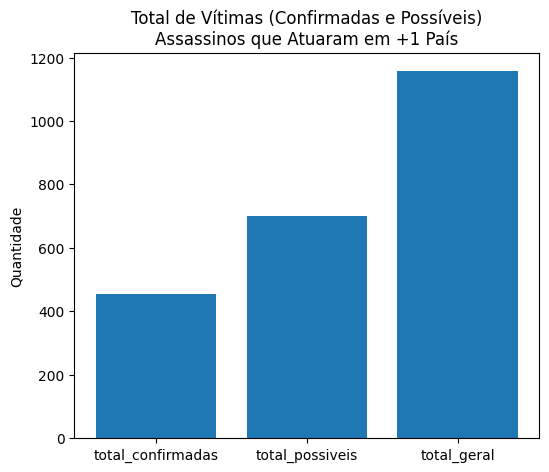

In [0]:
import matplotlib.pyplot as plt

spark.sql("""
CREATE OR REPLACE TEMP VIEW consulta1 AS
SELECT
    SUM(vitimas_provadas) AS total_confirmadas,
    SUM(vitimas_possiveis) AS total_possiveis,
    SUM(vitimas_provadas + vitimas_possiveis) AS total_geral
FROM workspace.public.fato_crimes
WHERE qtd_paises_atuacao > 1
""") 

df = spark.sql("SELECT * FROM consulta1")
display(df)

pdf = df.toPandas().T

pdf.columns = ["Quantidade"]

plt.figure(figsize=(6,5))
plt.bar(pdf.index, pdf["Quantidade"])

plt.title("Total de Vítimas (Confirmadas e Possíveis)\nAssassinos que Atuaram em +1 País")
plt.ylabel("Quantidade")

plt.show()


Consulta extra apenas para breve comparação ao final:

total_confirmadas,total_possiveis,total_geral
6746,10323,17069


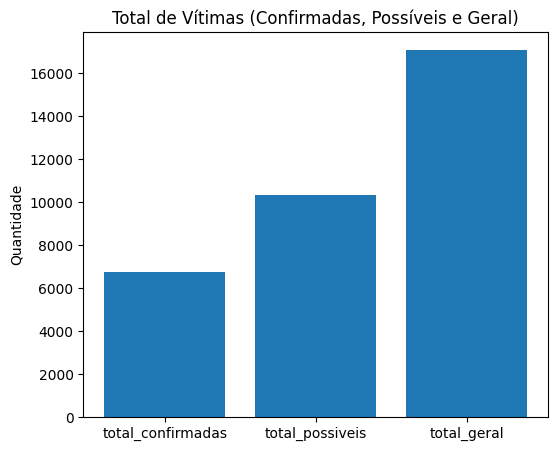

In [0]:
import matplotlib.pyplot as plt

df = spark.sql("""
--Para fins de comparação
SELECT
    SUM(vitimas_provadas) AS total_confirmadas,
    SUM(vitimas_possiveis) AS total_possiveis,
    SUM(vitimas_provadas + vitimas_possiveis) AS total_geral
FROM workspace.public.fato_crimes
""")

display(df)

pdf = df.toPandas().T
pdf.columns = ["Quantidade"]

plt.figure(figsize=(6,5))
plt.bar(pdf.index, pdf["Quantidade"])

plt.title("Total de Vítimas (Confirmadas, Possíveis e Geral)")
plt.ylabel("Quantidade")

plt.show()


Esta consulta agrega o número de vítimas entre assassinos cuja quantidade de países de atuação é superior a 1. A análise é relevante para avaliar se criminosos com atuação internacional tendem a apresentar maior letalidade em comparação àqueles que atuam apenas em um único país. Essa métrica pode indicar se a mobilidade geográfica está associada a um número maior de vítimas ou a padrões específicos de comportamento criminal.

Nos resultados que obtivemos, é possível observar que, de um total geral de 17069 vítimas totais, apenas 1156 são de assassinos que atuaram em mais de um país, o que é menos de 7%. Desse modo, pode-se avaliar que a quantidade de vítimas é inversamente proporcional ao número de países em que o criminoso atuou, julgando o cenário e o contexto criado.

## Consulta 2
Qual a idade média de início dos assassinatos por gênero?

--- Dados Coletados ---


genero,media_idade_inicio,qtd_amostra
MASCULINO,29.3,486
FEMININO,33.3,44


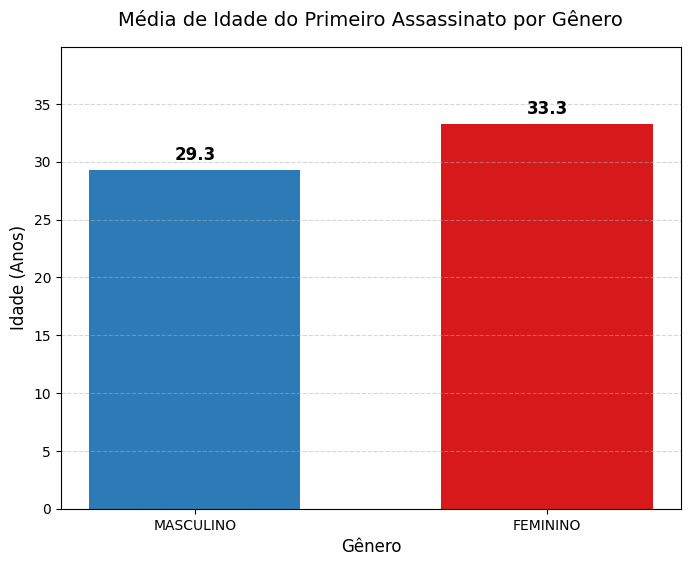

In [0]:
import matplotlib.pyplot as plt

query_view = """
CREATE OR REPLACE VIEW workspace.public.view_media_idade_genero AS
SELECT 
    d.genero,
    ROUND(AVG(f.idade_inicio), 1) as media_idade_inicio,
    COUNT(f.id_assassino) as qtd_amostra
FROM workspace.public.fato_crimes f
JOIN workspace.public.dim_assassino d ON f.id_assassino = d.id_assassino
WHERE f.idade_inicio > 0 
  AND d.genero != 'UNKNOWN'
GROUP BY d.genero
ORDER BY media_idade_inicio ASC
"""

spark.sql(query_view)

# carregar a tabela para uma lista de linhas
df_spark = spark.table("workspace.public.view_media_idade_genero")
dados_coletados = df_spark.collect()

# separar colunas em listas simples para eixo x e y
generos = [row['genero'] for row in dados_coletados]
idades = [row['media_idade_inicio'] for row in dados_coletados]

# tabela
print("--- Dados Coletados ---")
display(df_spark)

# grafico
plt.figure(figsize=(8, 6))

cores = ['#2c7bb6', '#d7191c'] 
barras = plt.bar(generos, idades, color=cores[:len(generos)], width=0.6)

for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width() / 2,
        altura + 0.5,
        f'{altura}',
        ha='center', 
        va='bottom', 
        fontsize=12, 
        fontweight='bold'
    )

plt.title('Média de Idade do Primeiro Assassinato por Gênero', fontsize=14, pad=15)
plt.ylabel('Idade (Anos)', fontsize=12)
plt.xlabel('Gênero', fontsize=12)
plt.ylim(0, max(idades) * 1.2) 
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

A visualização revela um padrão distinto entre os gêneros. Para os assassinos do gênero masculino, a média de início ocorre aos 29,3 anos. Esta fase corresponde a formação da vida adulta, o momento em que o indivíduo possui autonomia, mobilidade e recursos financeiros necessários para planejar assassinatos e ocultar provas, logísticas que seriam difíceis para um criminoso mais jovem ou adolescente.
Para o gênero feminino, o início é mais tardio, com média de 33,3 anos. Este dado reforça o perfil de crimes que precisam do estabelecimento de vínculos de longo prazo ou posições de confiança (como cuidadoras, enfermeiras ou esposas). Diferente da violência predatória e imediata comum aos homens, o modus operandi feminino muitas vezes depende de um acesso privilegiado às vítimas, algo conquistado apenas com a maturidade social e profissional.

## Consulta 3
A duração média dos anos em atividade dos Serial Killers diminuiu após o teste de DNA começar a ser usado em investigações criminais?

--- Tabela: Comparação Direta (Sem Transição) ---


era_investigacao,media_anos_atividade,qtd_amostra
1. Pré-DNA (Antes de 1986),5.9,210
2. Pós-DNA (1986 em diante),4.4,276


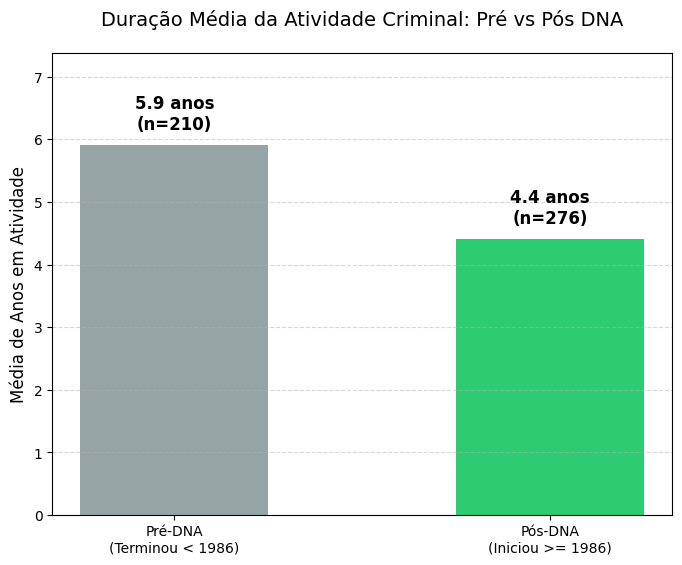

In [0]:
import matplotlib.pyplot as plt

query_dna_pure = """
CREATE OR REPLACE VIEW workspace.public.view_impacto_dna AS
SELECT 
    CASE 
        WHEN id_tempo_final < 1986 THEN '1. Pré-DNA (Antes de 1986)'
        ELSE '2. Pós-DNA (1986 em diante)'
    END AS era_investigacao,
    ROUND(AVG(anos_em_atividade), 1) as media_anos_atividade,
    COUNT(id_assassino) as qtd_amostra
FROM workspace.public.fato_crimes
WHERE id_tempo_final > 0 
  AND id_tempo_inicio > 0 
  AND anos_em_atividade >= 0
  -- AQUI ESTÁ O FILTRO: Excluímos quem viveu na transição
  -- Ou terminou antes de 86 (Pré Puro) OU começou depois de 86 (Pós Puro)
  AND (id_tempo_final < 1986 OR id_tempo_inicio >= 1986)
GROUP BY 1
ORDER BY 1 ASC
"""

spark.sql(query_dna_pure)

df_dna = spark.table("workspace.public.view_impacto_dna")
dados = df_dna.collect()

eras = [row['era_investigacao'] for row in dados]
medias = [row['media_anos_atividade'] for row in dados]
amostras = [row['qtd_amostra'] for row in dados]

print("--- Tabela: Comparação Direta (Sem Transição) ---")
display(df_dna)

plt.figure(figsize=(8, 6))

cores = ['#95a5a6', '#2ecc71'] 

barras = plt.bar(eras, medias, color=cores, width=0.5)

for i, barra in enumerate(barras):
    altura = barra.get_height()
    n = amostras[i]
    plt.text(
        barra.get_x() + barra.get_width() / 2, 
        altura + 0.2, 
        f'{altura} anos\n(n={n})', 
        ha='center', 
        va='bottom', 
        fontsize=12, 
        fontweight='bold'
    )

plt.title('Duração Média da Atividade Criminal: Pré vs Pós DNA', fontsize=14, pad=20)
plt.ylabel('Média de Anos em Atividade', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.ylim(0, max(medias) * 1.25)

plt.xticks(eras, ['Pré-DNA\n(Terminou < 1986)', 'Pós-DNA\n(Iniciou >= 1986)'])

plt.show()

A comparação entre os períodos puramente pré-DNA e pós-DNA revela uma diminuição significativa na vida criminal dos serial killers. Os dados indicam uma queda média de atividade de 5,9 anos antes de 1986 para 4,4 anos após 1986, representando uma redução de aproximadamente 25% da carreira criminal.

## Consulta 4
Comparando assassinos da "América do Sul" vs. "América do Norte", qual deles tem o maior número de serial killers com status “PRESO” para aqueles que iniciaram atividade nos anos "1990"?

continente,total_assassinos_presos
SOUTH AMERICA,8
NORTH AMERICA,35


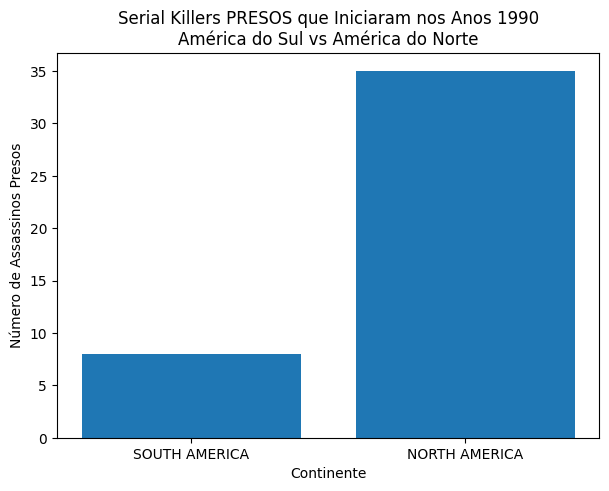

In [0]:
#View
import matplotlib.pyplot as plt

spark.sql("""
CREATE OR REPLACE TEMP VIEW consulta4 AS
SELECT
    l.continente,
    COUNT(DISTINCT a.id_assassino) AS total_assassinos_presos
FROM workspace.public.fato_crimes f
JOIN workspace.public.dim_assassino a
    ON f.id_assassino = a.id_assassino 
JOIN workspace.public.ponte_localizacao p
    ON a.id_assassino = p.id_assassino 
JOIN workspace.public.dim_localizacao l
    ON p.id_localizacao = l.id_localizacao
WHERE 
    l.continente IN ('NORTH AMERICA', 'SOUTH AMERICA')
    AND f.id_tempo_inicio BETWEEN 1990 AND 1999
    AND a.status = 'PRESO'
GROUP BY l.continente
""")

df = spark.sql("SELECT * FROM consulta4")
display(df)

pdf = df.toPandas()

plt.figure(figsize=(7,5))
plt.bar(pdf["continente"], pdf["total_assassinos_presos"])
plt.title("Serial Killers PRESOS que Iniciaram nos Anos 1990\nAmérica do Sul vs América do Norte")
plt.xlabel("Continente")
plt.ylabel("Número de Assassinos Presos")
plt.show()


> Consulta e plot apenas para finalidades comparativas:

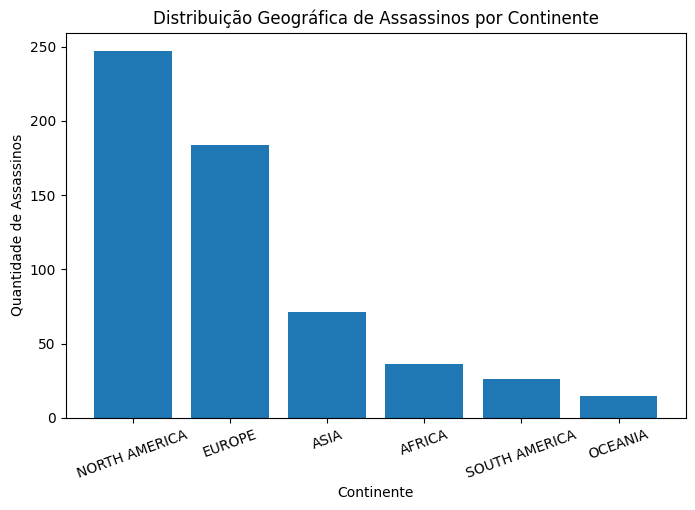

In [0]:
import matplotlib.pyplot as plt

df = spark.sql("""
    SELECT
        l.continente,
        COUNT(DISTINCT a.id_assassino) AS quantidade_assassinos
    FROM workspace.public.dim_assassino a
    JOIN workspace.public.ponte_localizacao p
        ON a.id_assassino = p.id_assassino
    JOIN workspace.public.dim_localizacao l
        ON p.id_localizacao = l.id_localizacao
    GROUP BY l.continente
    ORDER BY quantidade_assassinos DESC
""")

pdf = df.toPandas()

plt.figure(figsize=(8,5))
plt.bar(pdf["continente"], pdf["quantidade_assassinos"])
plt.title("Distribuição Geográfica de Assassinos por Continente")
plt.xlabel("Continente")
plt.ylabel("Quantidade de Assassinos")
plt.xticks(rotation=20)
plt.show()


Esta consulta compara o número de assassinos com status “PRESO” entre os que iniciaram sua atividade criminosa na década de 1990, segmentando os resultados entre a América do Sul e a América do Norte. Essa análise permite observar diferenças regionais tanto na incidência desses casos quanto na eficácia das investigações e prisões durante esse período. A comparação entre continentes oferece uma visão mais clara sobre variações geográficas no comportamento e no resultado final desses crimes.

A partir dos resultados, observa-se que o número de prisões é muito maior em países norte americanos, contudo, para que haja uma análise real, é necessário levar em consideração o número total de assassinos atuantes em ambos os continentes. Estatisticamente, a América do Norte tem mais assassinos que a América do Sul, o que pode acabar enviesando os resultados puros dessa consulta. Dessa forma, mostra-se essencial ter um escopo e contexto bem definidos ao analisar esse tipo de dado. Assim, proporcionalmente, aproximadamente 14% dos assassinos da década de 90 têm o status "PRESO" na América do Norte; já na América do Sul, essa porcentagem sobe para 30%.

# 6. Conclusões

O desenvolvimento deste projeto nos permitiu aplicar os conceitos de Data Warehousing vistos em sala de aula,
desde a extração de dados não estruturados até a carga final em um modelo dimensional.

As principais dificuldades enfrentadas incluíram:
- inconsistências e padrões variados na Wikipédia  
- necessidade de extração individual via API para gênero
- padronização de países e datas  
- criação da tabela ponte devido ao relacionamento muitos-para-muitos  

Alguns pontos positivos foram:
- aprender a usar bibliotecas e ferramentas de engenharia de dados
- entender a organização em camadas (Bronze/Prata/Ouro)  
- criar um modelo dimensional   
- desenvolver consultas analíticas   
- gerar visualizações que são úteis em análises  

As maiores limitações observadas durante o desenvovimento do trabalho:
- gênero nem sempre disponível diretamente 
- dados incompletos  
- ambiguidade em países e anos de atividade (ex. URSS e União Soviética; ou 1990-1999 e 1990s)  
- inconsistências da fonte podem impactar métricas


# 7. Contribuições dos Integrantes
A realização das tarefas foi distribuída entre os membros do grupo de acordo com suas habilidades, ritmo de trabalho e disponibilidade ao longo do desenvolvimento. A divisão ocorreu naturalmente, com cada integrante contribuindo significativamente em diferentes etapas.

### **Amanda Akemi Perina Kouchi**  
- Criação de tabelas (camada ouro) usando os dados da camada prata
- Implementação e interpretação de consultas analíticas

### **Daniel Oliveira Rocha**
- Implementação dos códigos de limpeza e padronização (camada prata)
- Implementação e interpretação de consultas analíticas

### **Contribuições conjuntas**
- Definição da modelagem e das regras de transformação
- Discussão sobre as perguntas analíticas
- Validação do pipeline de dados e dos resultados das consultas
- Realização do scraping dos dados (camada bronze)
- Organização e escrita do relatóro e notebook
